Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)


Load Dataset


In [ ]:
df = pd.read_csv("/content/E-commerce Shipping Dataset.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
df.shape

(10999, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


Dataset description and Basic Checks

In [ ]:
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


Encoding Categorical variable

In [ ]:
le = LabelEncoder()

categorical_cols = [
    "Warehouse_block",
    "Mode_of_Shipment",
    "Product_importance",
    "Gender"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


Drop Id

In [ ]:
df.drop("ID", axis=1, inplace=True)


Correlation Heatmap

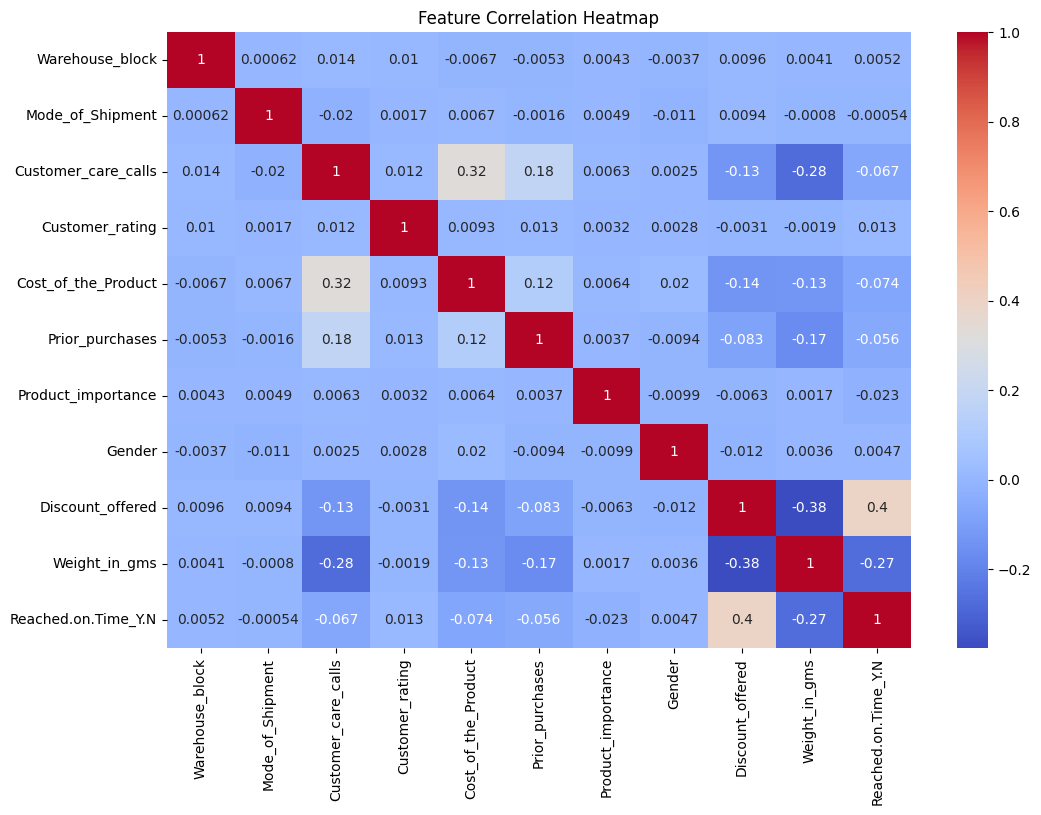

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


Imbalanced Dataset Visualization

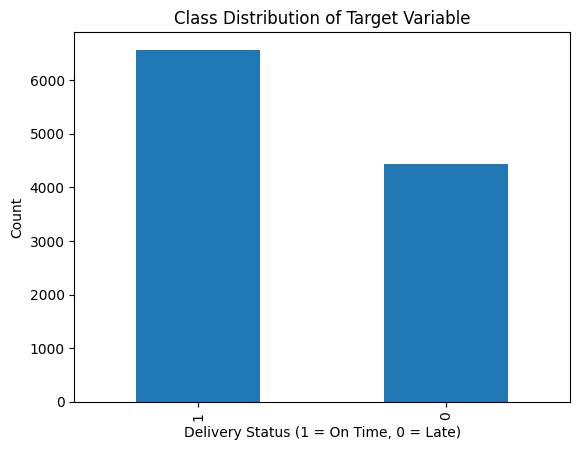

In [ ]:
df["Reached.on.Time_Y.N"].value_counts().plot(kind="bar")
plt.xlabel("Delivery Status (1 = On Time, 0 = Late)")
plt.ylabel("Count")
plt.title("Class Distribution of Target Variable")
plt.show()


Exploratory Data Analysis

Discount vs delivery status

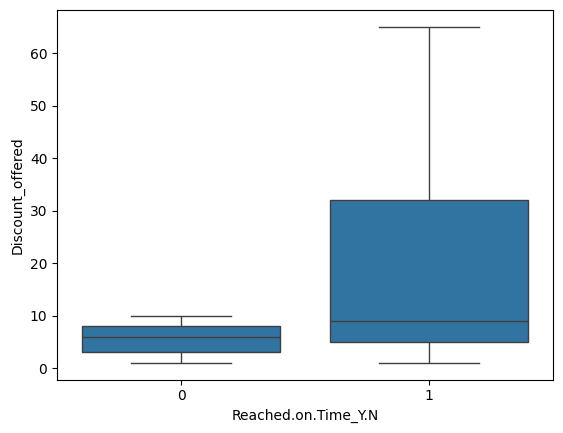

In [ ]:
sns.boxplot(x="Reached.on.Time_Y.N", y="Discount_offered", data=df)
plt.show()


weight vs delivery status

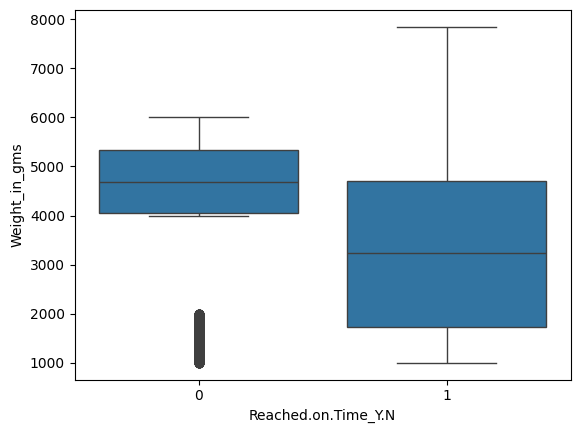

In [ ]:
sns.boxplot(x="Reached.on.Time_Y.N", y="Weight_in_gms", data=df)
plt.show()


Feature Scaling

In [ ]:
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Dataset spliting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Model training and testing

KNN Classifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


Logistic regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


Neural Network (MLP)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)


Model Evaluation Function

In [ ]:
def evaluate_model(name, y_test, y_pred):
    print(f"Model: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*50)


In [ ]:
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Neural Network", y_test, y_pred_mlp)


Model: KNN
Accuracy: 0.6477272727272727
Precision: 0.7252931323283082
Recall: 0.6595582635186595
Confusion Matrix:
 [[559 328]
 [447 866]]
--------------------------------------------------
Model: Decision Tree
Accuracy: 0.649090909090909
Precision: 0.7029257314328582
Recall: 0.7136329017517137
Confusion Matrix:
 [[491 396]
 [376 937]]
--------------------------------------------------
Model: Logistic Regression
Accuracy: 0.6363636363636364
Precision: 0.7040572792362768
Recall: 0.674028941355674
Confusion Matrix:
 [[515 372]
 [428 885]]
--------------------------------------------------
Model: Naive Bayes
Accuracy: 0.6481818181818182
Precision: 0.9769911504424779
Recall: 0.4204112718964204
Confusion Matrix:
 [[874  13]
 [761 552]]
--------------------------------------------------
Model: Neural Network
Accuracy: 0.6509090909090909
Precision: 0.7157561361836896
Recall: 0.6884996191926885
Confusion Matrix:
 [[528 359]
 [409 904]]
--------------------------------------------------


ROC Curve and AUC

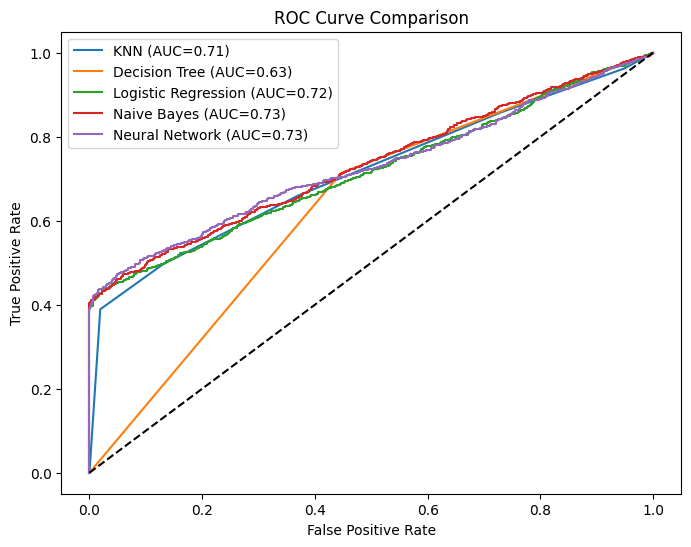

In [ ]:
models = {
    "KNN": knn,
    "Decision Tree": dt,
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Neural Network": mlp
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Accuracy Comparison Bar Chart

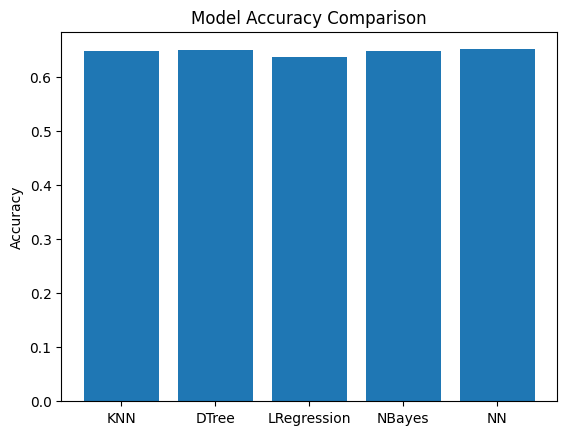

In [ ]:
accuracy_scores = {
    "KNN": accuracy_score(y_test, y_pred_knn),
    "DTree": accuracy_score(y_test, y_pred_dt),
    "LRegression": accuracy_score(y_test, y_pred_lr),
    "NBayes": accuracy_score(y_test, y_pred_nb),
    "NN": accuracy_score(y_test, y_pred_mlp)
}

plt.bar(accuracy_scores.keys(), accuracy_scores.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


Precision and Recall comparison of models

In [ ]:
models_pred = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "Neural Network": y_pred_mlp
}

precision_scores = {}
recall_scores = {}

for name, preds in models_pred.items():
    precision_scores[name] = precision_score(y_test, preds)
    recall_scores[name] = recall_score(y_test, preds)


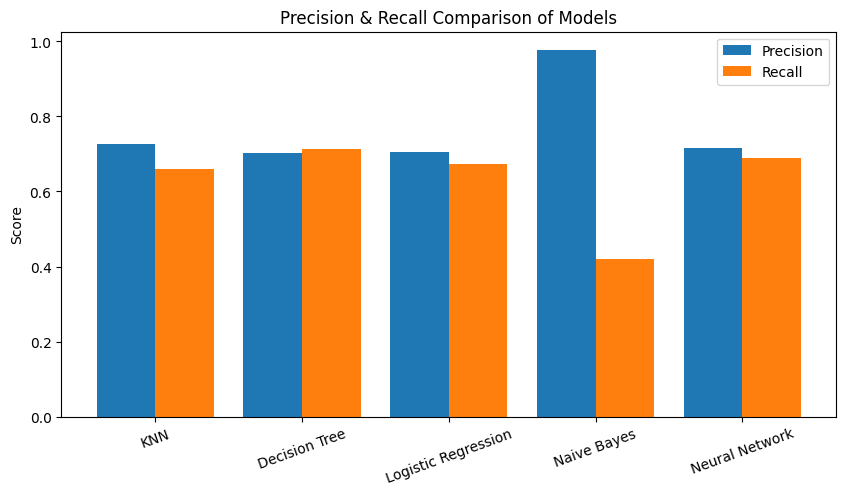

In [ ]:
x = np.arange(len(precision_scores))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, precision_scores.values(), width=0.4, label="Precision")
plt.bar(x + 0.2, recall_scores.values(), width=0.4, label="Recall")

plt.xticks(x, precision_scores.keys(), rotation=20)
plt.ylabel("Score")
plt.title("Precision & Recall Comparison of Models")
plt.legend()
plt.show()


Confusion Matrixx

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Late (0)", "On Time (1)"],
        yticklabels=["Late (0)", "On Time (1)"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


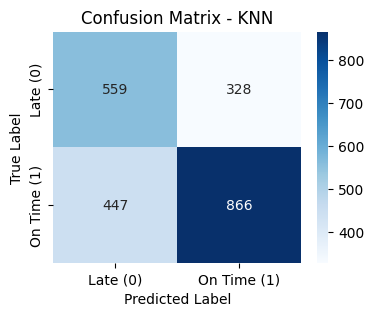

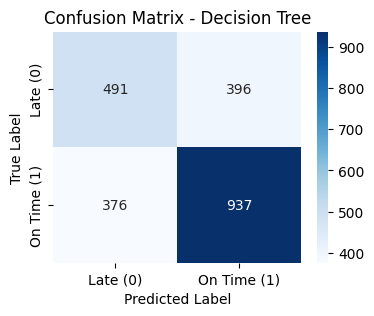

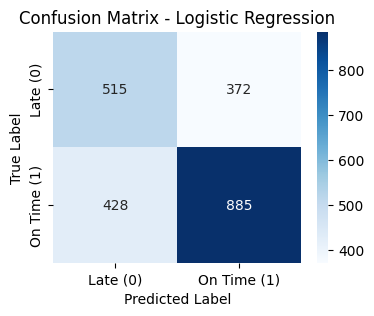

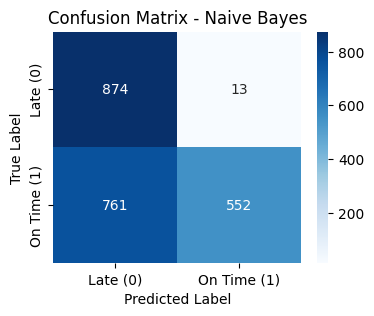

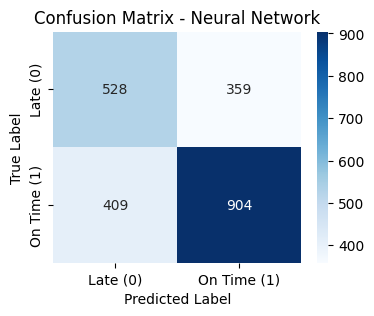

In [ ]:
plot_confusion_matrix(y_test, y_pred_knn, "KNN")
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")
plot_confusion_matrix(y_test, y_pred_mlp, "Neural Network")


Training Loss Curve

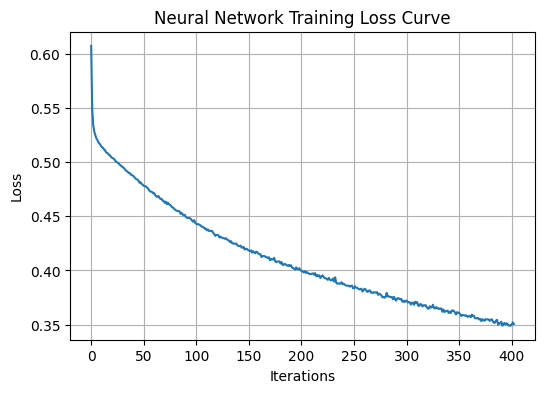

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss Curve")
plt.grid(True)
plt.show()


Unsupervised Learning- Kmeans

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df["Cluster"].value_counts()


,count
Cluster,
0,6079
1,2632
2,2288


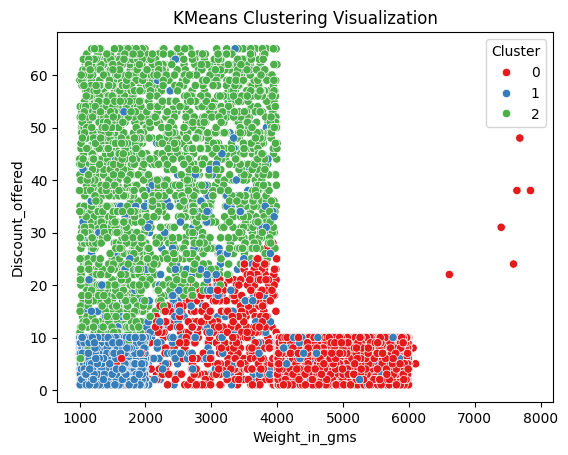

In [ ]:
sns.scatterplot(
    x=df["Weight_in_gms"],
    y=df["Discount_offered"],
    hue=df["Cluster"],
    palette="Set1"
)
plt.title("KMeans Clustering Visualization")
plt.show()
